In [1]:
import os
import torch
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
import tropycal.tracks as tracks
import matplotlib.patches as mpatches
import glob
import warnings
import aurora
from aurora import Tracker
from aurora import Batch, Metadata

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/tropycal/_version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Analyses for Hurricane Irene

Hurricane Irene was a large and powerful Atlantic hurricane that left extensive flood and wind damage along its path through the Caribbean, the United States East Coast and as far north as Canada. Irene made landfall near Cape Lookout, North Carolina at around 7:30 AM EDT on August 27, 2011 as a strong category 1 storm.

**More information:**

https://www.nhc.noaa.gov/data/tcr/AL092011_Irene.pdf

https://www.weather.gov/mhx/aug272011eventreview

https://www.weather.gov/gyx/Irene_Anniversary

### Storm Track Analysis

Calculate tracks for Aurora predictions. In here we are triggering tracking algorithm every 6-hour starting from 2011-08-21T00:00:00 to 2011-08-30T00:00:00. The number of steps used in the tracker is the actual distance to 2011-08-30T00:00:00 for each prediction. So, the number of steps is decreasing along with going forward in the prediction.

In [3]:
# Arguments
start_date = "2011-08-21T00:00:00"
start_date = datetime.strptime(start_date, "%Y-%m-%dT%H:%M:%S")
end_date = "2011-08-30T00:00:00"
end_date=datetime.strptime(end_date, "%Y-%m-%dT%H:%M:%S")
time_delta = 6
time_range = pd.date_range(start_date, end_date, freq=f"{time_delta}h").strftime('%Y-%m-%dT%H:%M:%S').to_list()

# Path for Aurora predictions
data_path = "/glade/derecho/scratch/turuncu/data/Data_aurora/predictions_irene/"

### Get track from HURDAT2 dataset

In [4]:
# Get best track data
basin = tracks.TrackDataset(basin='north_atlantic', source='hurdat', include_btk=True)
storm = basin.get_storm(("irene", 2011))
storm

--> Starting to read in HURDAT2 data
--> Completed reading in HURDAT2 data (1.62 seconds)
--> Starting to read in best track data
--> Completed reading in best track data (3.74 seconds)


<tropycal.tracks.Storm>
Storm Summary:
    Maximum Wind:      105 knots
    Minimum Pressure:  942 hPa
    Start Time:        0000 UTC 21 August 2011
    End Time:          1800 UTC 28 August 2011

Variables:
    time        (datetime) [2011-08-21 00:00:00 .... 2011-08-30 00:00:00]
    extra_obs   (int64) [0 .... 0]
    special     (str) [ .... ]
    type        (str) [TS .... EX]
    lat         (float64) [15.0 .... 53.0]
    lon         (float64) [-59.0 .... -60.0]
    vmax        (int64) [45 .... 40]
    mslp        (int64) [1006 .... 991]
    wmo_basin   (str) [north_atlantic .... north_atlantic]

More Information:
    id:              AL092011
    operational_id:  AL092011
    name:            IRENE
    year:            2011
    season:          2011
    basin:           north_atlantic
    source_info:     NHC Hurricane Database
    source:          hurdat
    ace:             18.8
    realtime:        False
    invest:          False
    subset:          False

### Run Aurora provided tracking tool over previously generated predictions

In [85]:
# Loop over files
init_lat=15.0
init_lon=-59.0
files = sorted(glob.glob(os.path.join(data_path, "pred_*.nc")))
for f in files:
    # Load dataset
    ds_aurora = xr.open_dataset(f)

    # Check output file
    ofile = f"track_{pd.to_datetime(ds_aurora.time.values[0]).strftime('%Y-%m-%dT%H:%M:%S')}.nc"
    #if os.path.exists(ofile):
    #    print(f"File {ofile} already exists. Skipping...")
    #    continue

    # Debugging
    print(f"Load {f} - {ds_aurora.time.values[0]} - {init_lat}/{init_lon}")
    
    # Init tracker
    tracker = Tracker(init_lat=init_lat, init_lon=init_lon, init_time=ds_aurora.time.values[0])

    # Loop over time steps
    for t in ds_aurora.time.values:
        # Create batch
        data = ds_aurora.sel(time=t)
        print(data)
        break
        batch = Batch(
            surf_vars={
                "2t": torch.from_numpy(data["2t"].values[None]),
                "10u": torch.from_numpy(data["10u"].values[None]),
                "10v": torch.from_numpy(data["10v"].values[None]),
                "msl": torch.from_numpy(data["msl"].values[None]),
            },
            static_vars={
                # The static variables are constant, so we just get them for the first time. They
                # don't need to be flipped along the latitude dimension, because they are from
                # ERA5.
                "z": torch.from_numpy(data["z"].values),
                "slt": torch.from_numpy(data["slt"].values),
                "lsm": torch.from_numpy(data["lsm"].values),
            },
            atmos_vars={
                "t": torch.from_numpy(data["t"].values[None]),
                "u": torch.from_numpy(data["u"].values[None]),
                "v": torch.from_numpy(data["v"].values[None]),
                "q": torch.from_numpy(data["q"].values[None]),
                "z": torch.from_numpy(data["z"].values[None]),
            },
            metadata=Metadata(
                # Flip the latitudes! We need to copy because converting to PyTorch, because the
                # data must be contiguous.
                lat=torch.from_numpy(data.latitude.values),
                lon=torch.from_numpy(data.longitude.values),
                # Converting to `datetime64[s]` ensures that the output of `tolist()` gives
                # `datetime.datetime`s. Note that this needs to be a tuple of length one:
                # one value for every batch element. Select the third time point.
                #time=(data.time.values.astype("datetime64[s]").tolist()[2],),
                time=(data.time.values,),
                atmos_levels=tuple(int(level) for level in data.level.values),
            ),
        )
        
        # Run tracker
        tracker.step(batch)
    
    # Store results
    if os.path.exists(ofile):
        os.remove(ofile)
    ds = xr.Dataset.from_dataframe(tracker.results())
    ds.to_netcdf(ofile)

    # Update init_lat and init_lon
    init_lat = ds.lat.values[1]
    init_lon = ds.lon.values[1]

Load /glade/derecho/scratch/turuncu/data/Data_aurora/predictions_irene/pred_2011-08-21T00:00:00.nc - 2011-08-21T00:00:00.000000000 - 15.0/-59.0
<xarray.Dataset> Size: 336MB
Dimensions:       (batch: 1, level: 13, latitude: 720, longitude: 1440)
Coordinates:
  * level         (level) int64 104B 1000 925 850 700 600 ... 250 200 150 100 50
  * latitude      (latitude) float32 3kB 90.0 89.75 89.5 ... -89.25 -89.5 -89.75
  * longitude     (longitude) float32 6kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    rollout_step  int64 8B ...
    time          datetime64[ns] 8B 2011-08-21
Dimensions without coordinates: batch
Data variables: (12/21)
    z             (batch, level, latitude, longitude) float32 54MB ...
    slt           (latitude, longitude) float32 4MB ...
    lsm           (latitude, longitude) float32 4MB ...
    2t            (batch, latitude, longitude) float32 4MB ...
    10u           (batch, latitude, longitude) float32 4MB ...
    10v           (batch, latitude, longitude) float32

IndexError: index 1 is out of bounds for axis 0 with size 1

### Run Aurora provided tracking tool using ERA5

In [98]:
# Create dataset
era5_path = '/glade/derecho/scratch/turuncu/data/Data_aurora/split_files'
files = sorted(glob.glob(os.path.join(era5_path, "data_*.nc")))
#ds = xr.open_mfdataset(files, data_vars="all", chunks='auto', engine="netcdf4").sel(time=time_range)
ds = xr.open_mfdataset(files, combine='by_coords', data_vars='all')
ds = ds.expand_dims('batch')

# Init tracker
init_lat=15.0
init_lon=-59.0
tracker = Tracker(init_lat=init_lat, init_lon=360+init_lon, init_time=ds.time.values[0])

# Loop over timesteps
for t in time_range:
    print(t)
    # Create batch
    data = ds.sel(time=t)
    batch = Batch(
        surf_vars={
            "2t": torch.from_numpy(data["t2m"].values[None]),
            "10u": torch.from_numpy(data["u10"].values[None]),
            "10v": torch.from_numpy(data["v10"].values[None]),
            "msl": torch.from_numpy(data["msl"].values[None]),
        },
        static_vars={
            "z": torch.from_numpy(data["hgt"].values),
            "slt": torch.from_numpy(data["slt"].values),
            "lsm": torch.from_numpy(data["lsm"].values),
        },
        atmos_vars={
            "t": torch.from_numpy(data["t"].values[None]),
            "u": torch.from_numpy(data["u"].values[None]),
            "v": torch.from_numpy(data["v"].values[None]),
            "q": torch.from_numpy(data["q"].values[None]),
            "z": torch.from_numpy(data["z"].values[None]),
        },
        metadata=Metadata(
            lat=torch.from_numpy(data.latitude.values),
            lon=torch.from_numpy(data.longitude.values),
            time=(data.time.values,),
            atmos_levels=tuple(int(level) for level in data.level.values),
        ),
    )

    # Run tracker
    tracker.step(batch)

# Store results
ofile = "track_era5.nc"
if os.path.exists(ofile):
    os.remove(ofile)
ds = xr.Dataset.from_dataframe(tracker.results())
ds.to_netcdf(ofile)

2011-08-21T00:00:00
2011-08-21T06:00:00
2011-08-21T12:00:00
2011-08-21T18:00:00
2011-08-22T00:00:00
2011-08-22T06:00:00
2011-08-22T12:00:00
2011-08-22T18:00:00
2011-08-23T00:00:00
2011-08-23T06:00:00
2011-08-23T12:00:00
2011-08-23T18:00:00
2011-08-24T00:00:00
2011-08-24T06:00:00
2011-08-24T12:00:00
2011-08-24T18:00:00
2011-08-25T00:00:00
2011-08-25T06:00:00
2011-08-25T12:00:00
2011-08-25T18:00:00
2011-08-26T00:00:00
2011-08-26T06:00:00
2011-08-26T12:00:00
2011-08-26T18:00:00
2011-08-27T00:00:00
2011-08-27T06:00:00
2011-08-27T12:00:00
2011-08-27T18:00:00
2011-08-28T00:00:00
2011-08-28T06:00:00
2011-08-28T12:00:00
2011-08-28T18:00:00
2011-08-29T00:00:00
2011-08-29T06:00:00
2011-08-29T12:00:00
2011-08-29T18:00:00
2011-08-30T00:00:00


### Create Tracking Plot

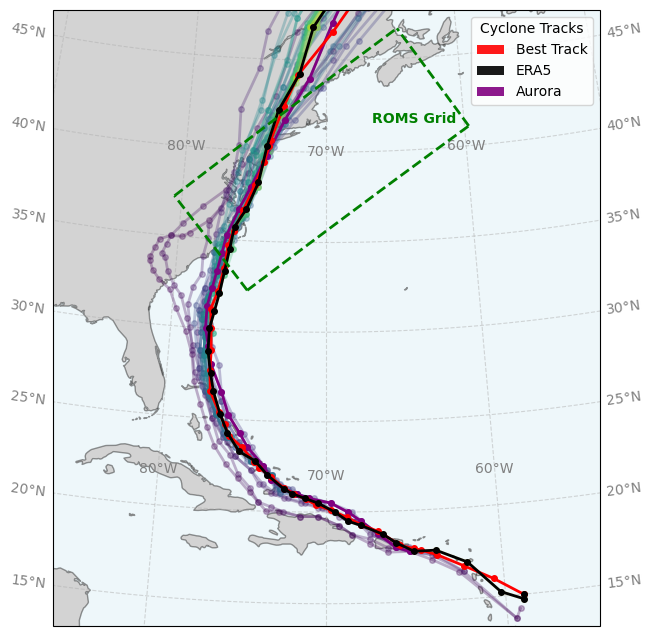

In [164]:
# Define bounding box limits
min_lat, max_lat = 13, 47
min_lon, max_lon = 275, 305

# Create figure with cartopy projection
plt.figure(figsize=(10, 8))
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0,
    central_latitude=(min_lat+max_lat)/2.0,
    standard_parallels=(20.0, 40.0)
)
ax = plt.axes(projection=projection)

# Add map features
ax.add_feature(cfeature.COASTLINE, alpha=0.4)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Axes
gl = ax.gridlines(crs=ccrs.PlateCarree(), alpha=0.5, linestyle='--', draw_labels=True)
gl.xlines = True
gl.ylines = True
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Plot Aurora
files = sorted(glob.glob("track_*.nc"))
alpha = 0.3
colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(files)-1))
id = 0
for f in files[1:]:
    ds = xr.open_dataset(f)
    color = id
    ax.plot(
        ds.lon,
        ds.lat,
        color=colors[id],
        alpha=alpha,
        marker="o",
        markersize=4,
        linewidth=2,
        label="Aurora",
        transform=ccrs.PlateCarree(),
    )
    id = id+1

# Plot Auora starting from 2011-08-21T06:00:00
ds_model = xr.open_dataset(files[5])
ax.plot(
    ds_model.lon,
    ds_model.lat,
    color="purple",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Aurora",
    transform=ccrs.PlateCarree(),
)

# Plot best track
ax.plot(
    storm.lon,
    storm.lat,
    color="red",
    marker="o",
    markersize=4,
    linewidth=2,
    label="HURDAT2",
    transform=ccrs.PlateCarree(),
)

# Plot ERA5
ds_era5 = xr.open_dataset("track_era5.nc")
ax.plot(
    ds.lon,
    ds.lat,
    color="black",
    marker="o",
    markersize=4,
    linewidth=2,
    label="ERA5",
    transform=ccrs.PlateCarree(),
)

# Add legend
best_patch = mpatches.Rectangle((0, 0), 1, 1, fc="red", alpha=0.9, label="Best Track")
era5_patch = mpatches.Rectangle((0, 0), 1, 1, fc="black", alpha=0.9, label="ERA5")
model_patch = mpatches.Rectangle((0, 0), 1, 1, fc="purple", alpha=0.9, label="Aurora")
ax.legend(handles=[best_patch, era5_patch, model_patch], loc="upper right", title="Cyclone Tracks")

# Add ROMS grid box
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')
ax.plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
ax.plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Top
ax.plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Left
ax.plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Right
ax.text(grid.lon_rho[0, -1]-7, grid.lat_rho[0, -1]+0.5, 'ROMS Grid', fontweight='bold', color='green', fontsize=10, transform=ccrs.PlateCarree())

# Save figure
plt.savefig(f"Fig_cyclone_tracks_irene.png", bbox_inches="tight", dpi=300)

In [186]:
# Prepare HURDAT2
x = pd.date_range(start_date, end_date, freq=f"{time_delta}h")
dict = {
    'time': [],
    'mslp': [],
    'vmax': []
}
for i in range(len(storm.lon)):
    if storm.time[i] in x:
        dict['time'].append(storm.time[i])
        dict['mslp'].append(storm.vars['mslp'][i])
        dict['vmax'].append(storm.vars['vmax'][i])

In [198]:
# Prepare Aurora Prediction from 2011-08-21T06:00:00
dict_model = {
    'time': [],
    'mslp': [],
    'vmax': []
}
for i in range(len(ds_model.index)):
    if ds_model.time.values[i] in x:
        dict_model['time'].append(ds_model.time.values[i])
        dict_model['mslp'].append(ds_model['msl'].values[i]/100.0)
        dict_model['vmax'].append(ds_model['wind'].values[i])

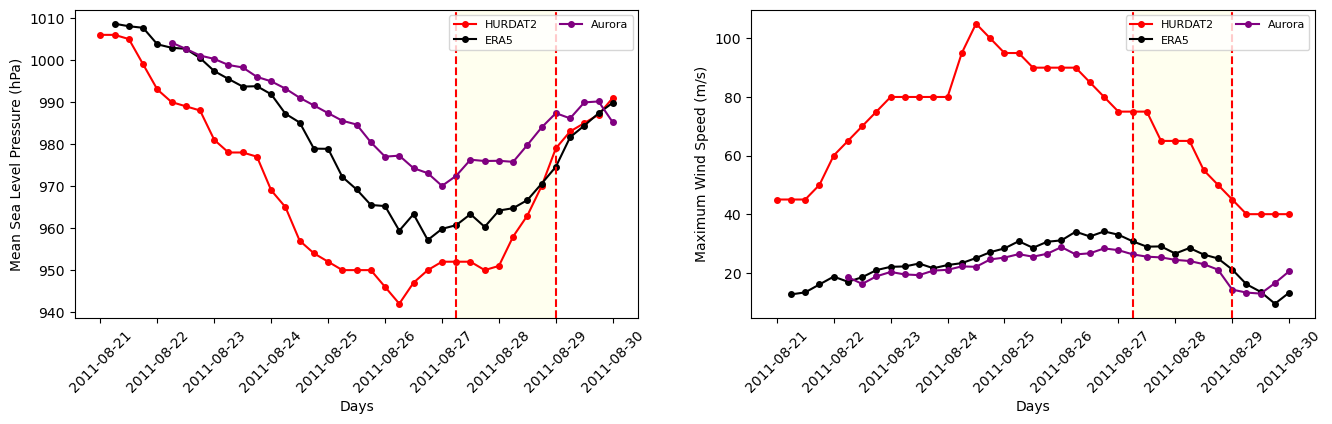

In [197]:
fig, ax = plt.subplots(1, 2, figsize=(16,4))
x = pd.date_range(start_date, end_date, freq=f"{time_delta}h")

ax[0].plot(x, dict['mslp'], color="red", marker="o", markersize=4, label="HURDAT2")
ax[0].plot(x, ds_era5['msl'][:-1]/100.0, color="black", marker="o", markersize=4, label="ERA5")
ax[0].plot(x[4:], dict_model['mslp'], color="purple", marker="o", markersize=4, label="Aurora")
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].legend(ncol=2, fontsize=8, loc='upper right')
ax[0].set_xlabel('Days')
ax[0].set_ylabel('Mean Sea Level Pressure (hPa)')
ax[0].axvline(x=x[25], color='r', linestyle='--') # 2011-08-27 06:00:00
ax[0].axvline(x=x[32], color='r', linestyle='--') # 2011-08-29T00:00:00
ax[0].axvspan(x[25], x[32], color='lightyellow', alpha=0.5)

ax[1].plot(x, dict['vmax'], color="red", marker="o", markersize=4, label="HURDAT2")
ax[1].plot(x, ds_era5['wind'][:-1], color="black", marker="o", markersize=4, label="ERA5")
ax[1].plot(x[4:], dict_model['vmax'], color="purple", marker="o", markersize=4, label="Aurora")
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].legend(ncol=2, fontsize=8, loc='upper right')
ax[1].set_xlabel('Days')
ax[1].set_ylabel('Maximum Wind Speed (m/s)')
ax[1].axvline(x=x[25], color='r', linestyle='--') # 2011-08-27 06:00:00
ax[1].axvline(x=x[32], color='r', linestyle='--') # 2011-08-29T00:00:00
ax[1].axvspan(x[25], x[32], color='lightyellow', alpha=0.5)

### Coupled Simulation Results

**Table 1:** Detailed information about conducted simulations
| #  | Data Component | Input     | Temporal Interpolation Type | Coupling Type      | Feedback                 |
|----|----------------|-----------|-----------------------------|--------------------|--------------------------|
| r1 | CDEPS          | ERA5 (6h) | coszen                      | one-way: ATM->OCN  | No                       |
| r2 | CDEPS          | ERA5 (1h) | coszen                      | one-way: ATM->OCN  | No                       |
| r3 | CDEPS          | ERA5 (6h) | linear                      | one-way: ATM->OCN  | No                       |
| r4 | CDEPS          | ERA5 (1h) | linear                      | one-way: ATM->OCN  | No                       |
| r5 | Aurora         | ERA5 (6h) | linear                      | one-way: ATM->OCN  | No                       |
| r6 | Aurora         | ERA5 (6h) | linear                      | two-way: ATM<->OCN | Yes, SST from OCN to ATM |

In [ ]:
# List of variables to keep
vars = {
    'Pair': [990, 1020],
    'Tair': [10, 30],
    'Uwind': [-20, 20],
    'Vwind': [-20, 20],
    'swrad': [0, 500],
    'lwrad': [-50, 100],
    'latent': [-100, 100],
    'sensible': [-100, 100]
}
var_names = list(vars.keys())

# Open datasets and merge them
ds1 = xr.open_dataset("../run_cdeps/r1/irene_his.nc")[var_names]
ds2 = xr.open_dataset("../run_cdeps/r2/irene_his.nc")[var_names]
ds3 = xr.open_dataset("../run_cdeps/r3/irene_his.nc")[var_names]
ds4 = xr.open_dataset("../run_cdeps/r4/irene_his.nc")[var_names]
ds5 = xr.open_dataset("../run/r5/irene_his.nc")[var_names]
ds6 = xr.open_dataset("../run/r6/irene_his.nc")[var_names]
ds = xr.concat([ds1, ds2, ds3, ds4, ds5, ds6], dim='run_id')

In [ ]:
dsx = xr.open_dataset("../run_cdeps/r1/irene_his.nc")
dsx

### Spatial plots for input forcing for each run

In [ ]:
# Define bounding box limits
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

# Create figure
nrow = ds.run_id.shape[0] # number of datasets
ncol = len(var_names) # number of variables
fig, ax = plt.subplots(
    nrow, 
    ncol, 
    figsize=(17, 8.5), 
    layout='constrained', 
    subplot_kw={'projection': projection})

# Set timestep
tindx = 10

# Add figure title
fig.suptitle(f"Time: {ds[var_name].isel(ocean_time=tindx).ocean_time.values}", fontsize=12)

# Add sub plots
im = []
for icol in range(ncol):
    for irow in range(nrow):
        var_name = var_names[icol]
        vmin, vmax = vars[var_name]
        im.append(ds[var_name].isel(run_id=irow, ocean_time=10).plot(ax=ax[irow,icol], transform=ccrs.LambertConformal(), vmin=vmin, vmax=vmax, cmap='viridis', add_colorbar=False))
        if irow == 0:
            ax[irow,icol].set_title(var_name)
        else:
            ax[irow,icol].set_title("")
        if icol == 0:
            ax[irow,icol].text(-0.1, 0.5, f"R{irow+1}", transform=ax[irow,icol].transAxes, rotation=90, ha='center', va='center', fontsize=12)
        ax[irow,icol].coastlines()
    fig.colorbar(im[-1], ax=ax[:,icol], location='bottom', pad=0.01, aspect=20, shrink=0.8, label=ds[var_name].units)

### Spatial plot from ROMS

In [ ]:
var = "zeta"
ds5 = xr.open_dataset("../run/r5/irene_his.nc").isel(s_rho=-1)[[var]]
ds6 = xr.open_dataset("../run/r6/irene_his.nc").isel(s_rho=-1)[[var]]

In [ ]:
fig, ax = plt.subplots(
    1, 
    3, 
    figsize=(17, 8.5), 
    layout='constrained', 
    subplot_kw={'projection': projection})

data1 = ds5[var].mean(dim='ocean_time')
plot1 = data1.plot(
    x="lon_rho", 
    y="lat_rho",
    ax=ax[0],
    transform=ccrs.PlateCarree(), 
    vmin=-1, 
    vmax=1,
    cmap='viridis',
    add_colorbar=False)
ax[0].coastlines(resolution='50m', color='black', linewidth=1)
ax[0].set_title("")

data2 = ds6[var].mean(dim='ocean_time')
plot2 = data2.plot(
    x="lon_rho", 
    y="lat_rho",
    ax=ax[1],
    transform=ccrs.PlateCarree(), 
    vmin=-1, 
    vmax=1,
    cmap='viridis',
    add_colorbar=False)
ax[1].coastlines(resolution='50m', color='black', linewidth=1)
ax[1].set_title("")

diff = data2-data1
plot3 = diff.plot(
    x="lon_rho", 
    y="lat_rho",
    ax=ax[2],
    transform=ccrs.PlateCarree(), 
    vmin=-0.05, 
    vmax=0.05,
    cmap='RdBu_r',
    add_colorbar=False)
ax[2].coastlines(resolution='50m', color='black', linewidth=1)
ax[2].set_title("")

### 

In [ ]:
ds_o = xr.open_dataset('irene_sst_20110827.nc4')

In [ ]:
ds_o

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
im = ax_local.imshow(data, cmap='plasma', aspect=4)

### Atmospheric Analyses